# MiniGPT — Training

In [1]:
from src.config import Config
from src.utils import set_seed, initialize_weights, count_parameters, plot_loss_curve
from src.data import prepare_data, preprocess_text, get_batch
from src.model import MiniGPT
from src.train import train_model

config = Config()
device = config.device
print("Device:", device)

Device: cuda


In [10]:
config.block_size = 128
config.embedding_dim = 160
config.n_head = 8
config.n_layer = 6

config.batch_size = 64
config.max_iters = 10000
config.eval_interval = 250
config.eval_iters = 100

print(config)
print("Device:", config.device)

Config(data_path='data/input.txt', model_dir='models', checkpoint_name='mini_gpt_checkpoint.pth', best_model_name='mini_gpt_best.pth', data_fraction=0.1, train_split=0.9, block_size=128, embedding_dim=160, n_head=8, n_layer=6, dropout=0.0, batch_size=64, learning_rate=0.0002, weight_decay=0.01, max_iters=10000, eval_interval=250, eval_iters=100, seed=42)
Device: cuda


In [11]:
set_seed(config.seed)

text, tokenizer, train_data, val_data = prepare_data(
    path="data/input.txt",
    fraction=config.data_fraction,
    train_split=config.train_split
)

Original length: 111539
Cleaned length: 106823
Vocabulary size: 29
['\n', ' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Train characters: 96140
Validation characters: 10683


In [12]:
model = MiniGPT(
    vocab_size=tokenizer.vocab_size,
    block_size=config.block_size,
    embedding_dim=config.embedding_dim,
    n_head=config.n_head,
    n_layer=config.n_layer,
    dropout=config.dropout
).to(config.device)

model.apply(initialize_weights)
summary = count_parameters(model)

Total trainable parameters: 1,882,880
Total parameters in millions: 1.88M

---------------------------------------------------------------------------
embedding.token_embedding.weight                                  4,640
embedding.position_embedding.weight                              20,480
blocks.0.ln1.weight                                                 160
blocks.0.ln1.bias                                                   160
blocks.0.attention.heads.0.query.weight                           3,200
blocks.0.attention.heads.0.key.weight                             3,200
blocks.0.attention.heads.0.value.weight                           3,200
blocks.0.attention.heads.1.query.weight                           3,200
blocks.0.attention.heads.1.key.weight                             3,200
blocks.0.attention.heads.1.value.weight                           3,200
blocks.0.attention.heads.2.query.weight                           3,200
blocks.0.attention.heads.2.key.weight                    

In [13]:
x, y = get_batch(
    train_data,
    config.batch_size,
    config.block_size,
    config.device
)

logits = model(x)

print("Input shape :", x.shape)
print("Target shape:", y.shape)
print("Logits shape:", logits.shape)

Input shape : torch.Size([64, 128])
Target shape: torch.Size([64, 128])
Logits shape: torch.Size([64, 128, 29])


In [14]:
results = train_model(
    model=model,
    train_data=train_data,
    val_data=val_data,
    config=config,
    tokenizer=tokenizer
)

Iteration     1 | Train Loss: 3.1235 | Val Loss: 3.1200
  Saved best model -> models/mini_gpt_best.pth
Iteration   250 | Train Loss: 2.2812 | Val Loss: 2.3106
  Saved best model -> models/mini_gpt_best.pth
Iteration   500 | Train Loss: 2.1898 | Val Loss: 2.2343
  Saved best model -> models/mini_gpt_best.pth
Iteration   750 | Train Loss: 2.1290 | Val Loss: 2.1916
  Saved best model -> models/mini_gpt_best.pth
Iteration  1000 | Train Loss: 2.0706 | Val Loss: 2.1400
  Saved best model -> models/mini_gpt_best.pth
Iteration  1250 | Train Loss: 1.9279 | Val Loss: 1.9961
  Saved best model -> models/mini_gpt_best.pth
Iteration  1500 | Train Loss: 1.8284 | Val Loss: 1.9038
  Saved best model -> models/mini_gpt_best.pth
Iteration  1750 | Train Loss: 1.7652 | Val Loss: 1.8498
  Saved best model -> models/mini_gpt_best.pth
Iteration  2000 | Train Loss: 1.7160 | Val Loss: 1.8163
  Saved best model -> models/mini_gpt_best.pth
Iteration  2250 | Train Loss: 1.6946 | Val Loss: 1.7939
  Saved best mode

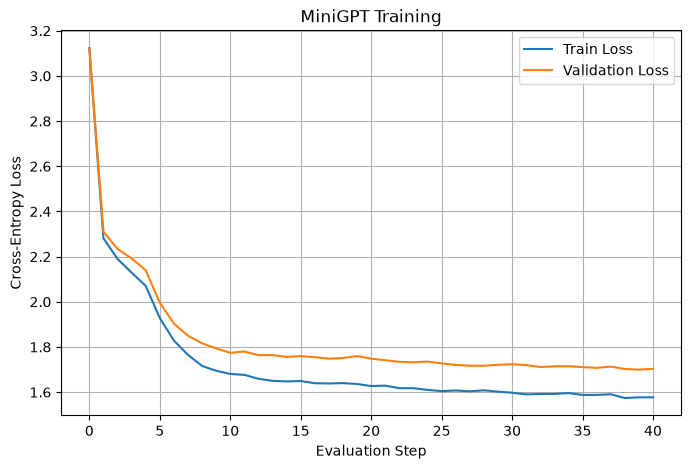

In [15]:
plot_loss_curve(
    results["train_losses"],
    results["val_losses"]
)

## Final evaluation of the best checkpoint

In [16]:
from src.utils import load_checkpoint, perplexity
import torch.nn as nn

best_model, best_checkpoint = load_checkpoint(
    config.best_model_path,
    MiniGPT,
    config.device
)

loss_fn = nn.CrossEntropyLoss()

final_losses = __import__("src.train", fromlist=["estimate_loss"]).estimate_loss(
    best_model,
    train_data,
    val_data,
    loss_fn,
    config.batch_size,
    config.block_size,
    config.device,
    config.eval_iters
)

print(f"Train Loss: {final_losses['train']:.4f}")
print(f"Val Loss  : {final_losses['val']:.4f}")
print(f"Train Perplexity: {perplexity(final_losses['train']):.2f}")
print(f"Val Perplexity  : {perplexity(final_losses['val']):.2f}")

Train Loss: 1.5754
Val Loss  : 1.6985
Train Perplexity: 4.83
Val Perplexity  : 5.47
